In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
from matplotlib import pyplot as plt 
import warnings
warnings.filterwarnings("ignore")

### implementation of our own DBSCAN

In [9]:
class My_DBSCAN: 
    def __init__(self , eps = 0.5 , min_pts = 5): 
        self.eps = eps
        self.min_pts = min_pts
        self.labels_ = None 
    
    def fit(self , X):
        n = X.shape[0] # number of rows
        # initially all index(rows) cluster(label) is -1(noise)
        self.labels_ = np.full(shape = n , fill_value = -1)
        visited = np.zeros(shape = n , dtype = bool) # track a row is visited or not 
        cluster_id = 0 

        # go to each point 
        for i in range(n): 
            # if visited then skip, cause already proccessed 
            if visited[i]: 
                continue

            # otherwise mark as visited 
            visited[i] = True

            # find the neighbors(points within the epsilon distance) of i-th point 
            neighbors = self._region_query(X , i) 

            # now if i-th point has less than MinPts points means it's a noise point 
            if len(neighbors) < self.min_pts: 
               self.labels_[i] = -1 # mark as noise
            else: # find it's a core or boundary point 
                self._expand_cluster(X , i , neighbors , cluster_id , visited)
                cluster_id += 1
        
        return self       

    def _region_query(self , X , idx): 
        """Find all points within epsilon distance of point idx."""
        distances = np.linalg.norm(X - X[idx] , axis = 1) # finding equclidean distance
        return np.where(distances <= self.eps)[0]

    def _expand_cluster(self , X , idx , neighbors , cluster_id , visited): 
        """Expand a new cluster from seed point."""
        self.labels_[idx] = cluster_id
        i = 0 
        while i < len(neighbors): 
            point = neighbors[i]

            if not visited[point]: 
                visited[point] = True
                point_neighbors = self._region_query(X , point)

                if len(point_neighbors) >= self.min_pts: 
                    neighbors = np.concatenate((neighbors, point_neighbors))

            if self.labels_[point] == -1: # previously marked as noise 
                self.labels_[point] = cluster_id # add it to the current cluster

            i += 1

In [4]:
a = np.array([[1,2] , [2,3] , [3,4] , [4,5]]) # X
b = a[0] # idx val
c = a - b
print(f"c: {c}")
dis = np.linalg.norm(c , axis = 1)
dis # equclidean distance

c: [[0 0]
 [1 1]
 [2 2]
 [3 3]]


array([0.        , 1.41421356, 2.82842712, 4.24264069])

In [5]:
np.where(dis <= 0.5)

(array([0]),)

In [7]:
from sklearn.datasets import make_moons
X, _ = make_moons(n_samples = 300 , noise = 0.05 , random_state = 42)

In [10]:
db = My_DBSCAN(eps = 0.2 , min_pts = 5)
db.fit(X)

labels = db.labels_

In [11]:
labels

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1])

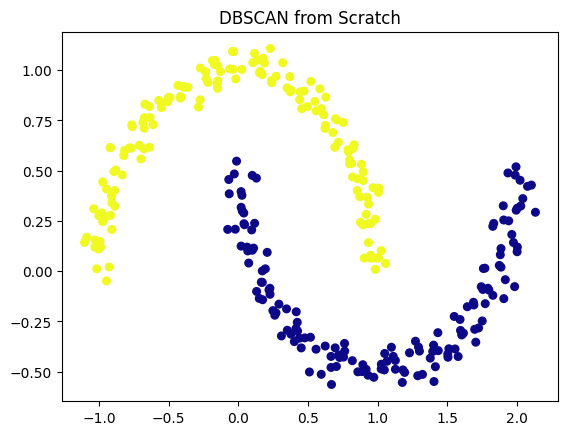

In [12]:
plt.scatter(X[ : , 0] , X[ : , 1] , c = labels , cmap = "plasma" , s = 30)
plt.title("DBSCAN from Scratch")
plt.show()

### Measuring Quality of Clusters

In [14]:
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score , davies_bouldin_score , calinski_harabasz_score

In [15]:
X, y_true = make_blobs(n_samples = 500 , centers = 4, cluster_std = 0.60 , random_state = 42)

In [16]:
dbscan = DBSCAN(eps = 0.8 , min_samples = 5)
y_pred = dbscan.fit_predict(X)

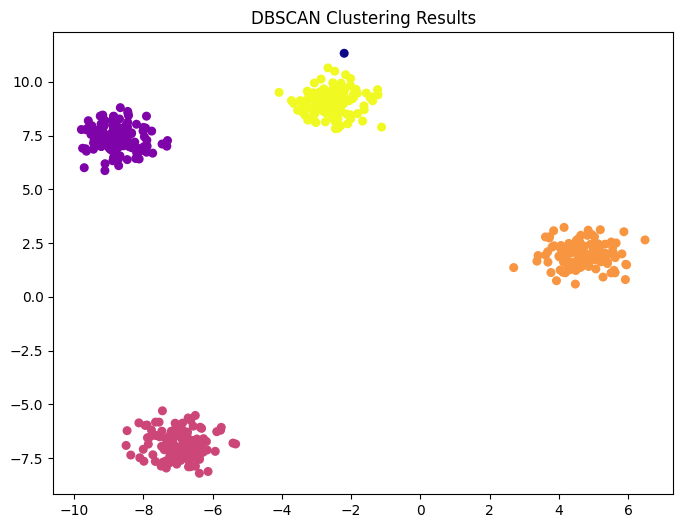

In [17]:
# Visualize clusters
plt.figure(figsize = (8 , 6))
plt.scatter(X[ : , 0] , X[ : , 1] , c = y_pred , cmap = 'plasma', s = 30)
plt.title("DBSCAN Clustering Results")
plt.show()

In [18]:
# Evaluate cluster quality 

mask = y_pred != -1 # avoid the noise points 

if len(set(y_pred)) > 1 and np.any(mask):
    sil = silhouette_score(X[mask] , y_pred[mask])
    dbi = davies_bouldin_score(X[mask] , y_pred[mask])
    chi = calinski_harabasz_score(X[mask] , y_pred[mask])

    print(f"Silhouette Score: {sil:.3f}  (higher is better , max = 1)")
    print(f"Davies-Bouldin Index: {dbi:.3f}  (lower is better)")
    print(f"Calinski-Harabasz Index: {chi:.3f}  (higher is better)")
else:
    print("Not enough clusters to evaluate (all noise or one cluster).")

Silhouette Score: 0.876  (higher is better , max = 1)
Davies-Bouldin Index: 0.174  (lower is better)
Calinski-Harabasz Index: 16059.425  (higher is better)
